# Distances: KL and JS Divergences, LSE

This seminar covers different distribution modeling approaches and their pros and cons

### Contents:

1. Initialization and Data Generation
2. Modeling unimodal 2D distribution: KL Loss
3. Better of two worlds: JS Loss
4. Straighforward approach: Least Squares
5. Modeling 1D distribution


## Initialization and Data Generation

In [1]:
# !pip install -q jupyter-black

In [2]:
%load_ext jupyter_black

In [3]:
import matplotlib.pyplot as plt
from matplotlib import style
style.use('fivethirtyeight')
%matplotlib inline

import numpy as np

import torch
from torch import distributions
from torch.distributions.multivariate_normal import MultivariateNormal

from IPython.display import clear_output

Wrapper for our multivariate distribution

In [4]:
class DistributionHandler:
    def __init__(self, mu=0.0, sigma=1.0):
        """
        Initialize a distribution handler with mean and covariance parameters.

        Parameters:
        mu (float): Mean of the distribution (default 0.0).
        sigma (float): Standard deviation for covariance matrix (default 1.0).
        """
        self.mu = mu if not isinstance(mu, float) else torch.Tensor([mu, mu])
        self.sigma = sigma if not isinstance(sigma, float) else torch.Tensor([[sigma, 0], [0, sigma]])
        self.distribution = self.create_distribution()

    def create_distribution(self):
        """
        Create a multivariate normal distribution with the current parameters.

        Returns:
        distrs.MultivariateNormal: The initialized distribution.
        """
        return distributions.MultivariateNormal(self.mu, self.sigma)

    def make_trainable(self):
        self.mu.requires_grad = True
        self.sigma.requires_grad = True
        return self.mu, self.sigma

    def sample(self, num_samples):
        """
        Sample points from the current distribution.

        Parameters:
        num_samples (int): Number of points to sample.

        Returns:
        torch.Tensor: Sampled points.
        """
        return self.distribution.sample(torch.Size([num_samples]))

Helper function for drawing

In [5]:
def plot_2d_dots(dots, color='blue', label='None'):
    """
    Plot a 2D scatter plot for a given set of points.

    Parameters:
    dots (torch.Tensor): Points to plot, should be of shape (N, 2).
    color (str): Color of the points (default 'blue').
    label (str): Label for the points (default 'None').
    """
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.scatter(dots[:, 0], dots[:, 1], s=5, c=color, label=label)
    plt.xlabel("X_1")
    plt.ylabel("X_2")


### Target distribution

***x*** - samples from the target distribution

***p(x)*** - probability of target samples for the target distribution


In [6]:
mu = torch.Tensor([-5, -5])
sigma = torch.Tensor([[1, 0],
                      [0, 1]])

dist = DistributionHandler(mu, sigma)

x = dist.sample(1000)
px = dist.distribution.log_prob(x).exp()

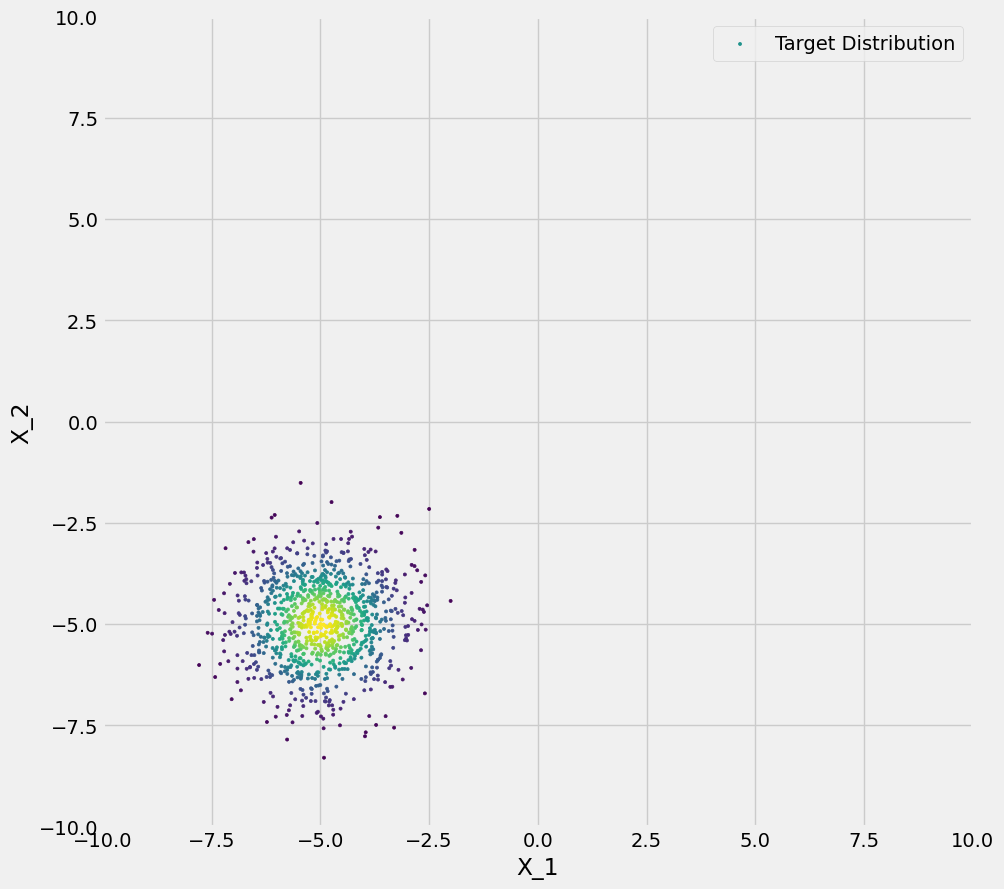

In [7]:
plt.figure(figsize=(10, 10))
plot_2d_dots(x, color=px, label='Target Distribution')
plt.legend()
plt.show()

### Initialize our starting points

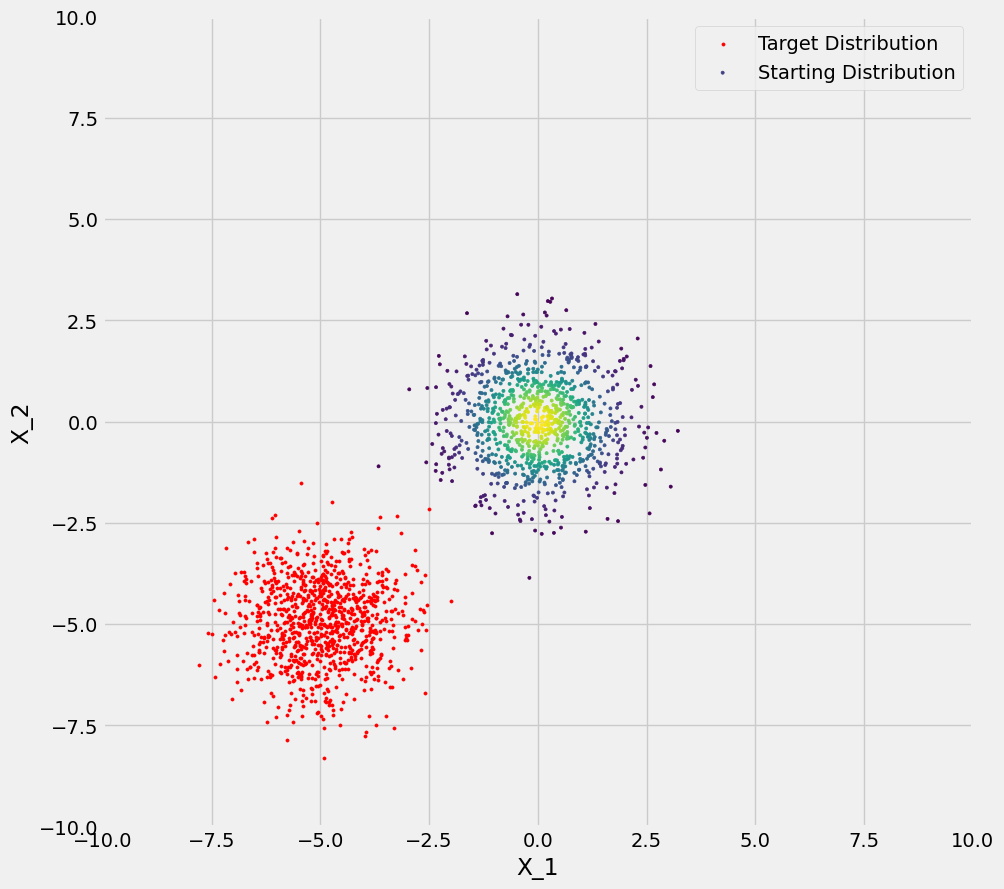

In [8]:
Q = DistributionHandler(0., 1.)
q_sample = Q.sample(1000)
qx = Q.distribution.log_prob(q_sample).exp()

plt.figure(figsize=(10, 10))
plot_2d_dots(x, color='r', label='Target Distribution')
plot_2d_dots(q_sample, color=qx, label='Starting Distribution')

plt.legend()
plt.show()

______

## KL Divergence Loss
The Kullback-Leibler (KL) divergence measures how one probability distribution $q(x)$ differs from a target distribution $p(x)$.


#### Formula
The formula for KL divergence is given by:
$$
D_{KL}(P \parallel Q) = \sum_x P(x) \log\left(\frac{P(x)}{Q(x)}\right)
$$

In this implementation, we compute the weighted KL divergence loss using the formula:
$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^N w_i P(x_i) \left[ \log P(x_i) - \log Q(x_i) \right]
$$
Here, $w_i$ represents optional weights for importance sampling, and clamping ensures numerical stability by avoiding logarithms of very small probabilities.


In [9]:
def kl_loss(px, qx, weights=None):
    """
    Compute the Kullback-Leibler (KL) divergence loss between two probability distributions.

    Parameters:
    px (torch.Tensor): Target probability distribution.
    qx (torch.Tensor): Predicted probability distribution.
    weights (torch.Tensor, optional): Importance sampling weights (default None).

    Returns:
    torch.Tensor: The KL divergence loss.
    """
    # Clamp probabilities for numerical stability
    px, qx = px.clamp(min=1e-7), qx.clamp(min=1e-7)

    # Assign default weights if none are provided
    if weights is None:
        weights = torch.ones_like(px)

    # Compute the weighted KL divergence
    return torch.mean(weights * px * (px.log() - qx.log()))

In [10]:
def train_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=5000, plot_interval=200, loss_fn=kl_loss, title='KL Divergence Training', **loss_kwargs):
    """
    Train a distribution to match a target distribution using a specified loss function.

    Parameters:
    train_mu (torch.Tensor): Trainable mean of the distribution.
    train_sigma (torch.Tensor): Trainable covariance matrix of the distribution.
    px (torch.Tensor): Target probability distribution values.
    x (torch.Tensor): Target data points.
    lr (float): Learning rate for the optimizer (default 0.1).
    iterations (int): Number of training iterations (default 5000).
    plot_interval (int): Interval for plotting visualizations (default 200).
    loss_fn (function): Loss function to use for optimization (default kl_loss).
    title (str): Title for the plot visualizations (default 'KL Divergence Training').
    loss_kwargs: Additional keyword arguments to pass to the loss function.
    """

    optimizer = torch.optim.Adam([train_mu, train_sigma], lr=lr)

    for i in range(iterations):
        optimizer.zero_grad()

        # Create distribution using current parameters
        Q = DistributionHandler(train_mu, train_sigma)

        # Compute probability of target samples under the train distribution
        qx = Q.distribution.log_prob(x).exp()

        loss = loss_fn(px, qx, **loss_kwargs)

        loss.backward()

        optimizer.step()

        # Visualization every `plot_interval` iterations
        if i % plot_interval == 0:
            clear_output(True)
            plt.figure(figsize=(10, 10))
            plt.title(f'{title}: Loss={loss.item():.4f}, Iteration={i}')

            # Plot target distribution
            plot_2d_dots(x, color='red', label='Target Distribution')

            # Sample and plot from the train distribution
            q_sample = Q.sample(1000)
            qx = Q.distribution.log_prob(q_sample).exp().detach()

            plot_2d_dots(q_sample, color=qx, label='Train Distribution')

            plt.legend()
            plt.show()


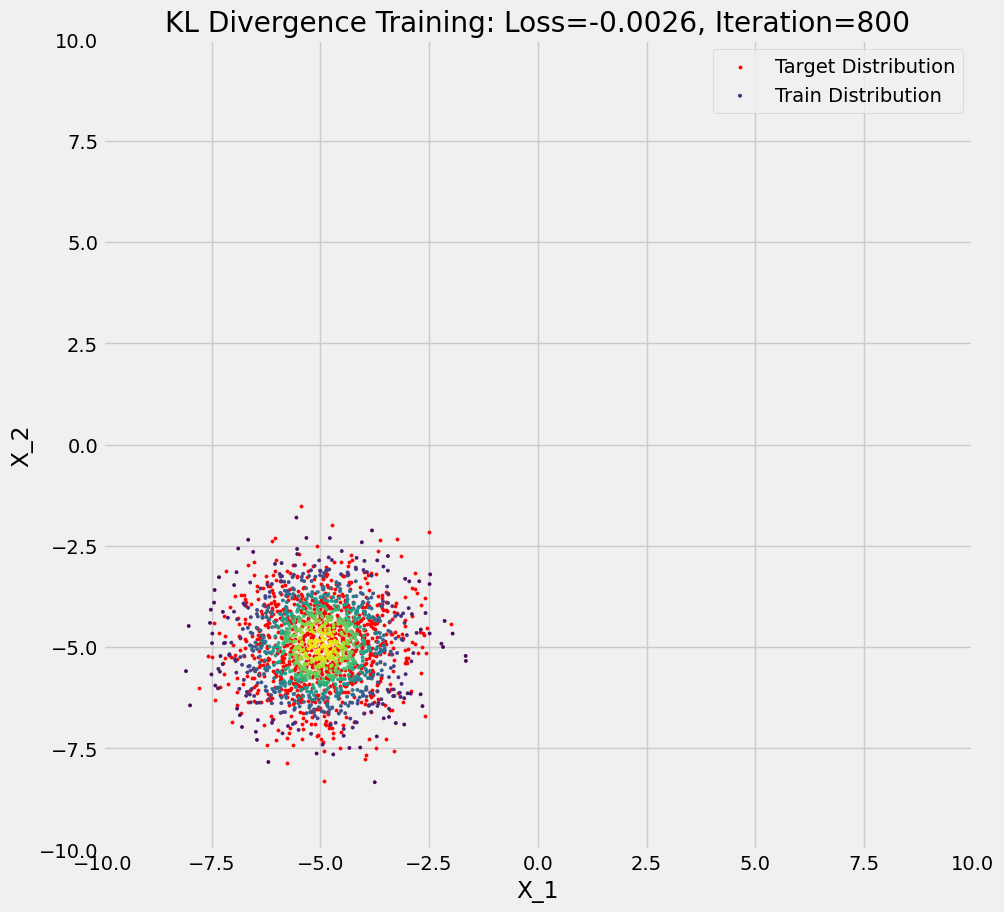

In [11]:
train_mu, train_sigma = Q.make_trainable()

train_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=1000, plot_interval=200, loss_fn=kl_loss, title='KL Divergence Training', weights=1./px)

### Problem with KL

What happends if we have two target distributions?

In [12]:
target1 = DistributionHandler(torch.Tensor([-5, -5]), torch.Tensor([[1., 0.0], [0.0, 1.]]))
target2 = DistributionHandler(torch.Tensor([4, 3]), torch.Tensor([[1., 0.0], [0.0, 1.]]))

x = torch.cat([target1.sample(1000), target2.sample(1000)])

px = target1.distribution.log_prob(x).exp() + target2.distribution.log_prob(x).exp()

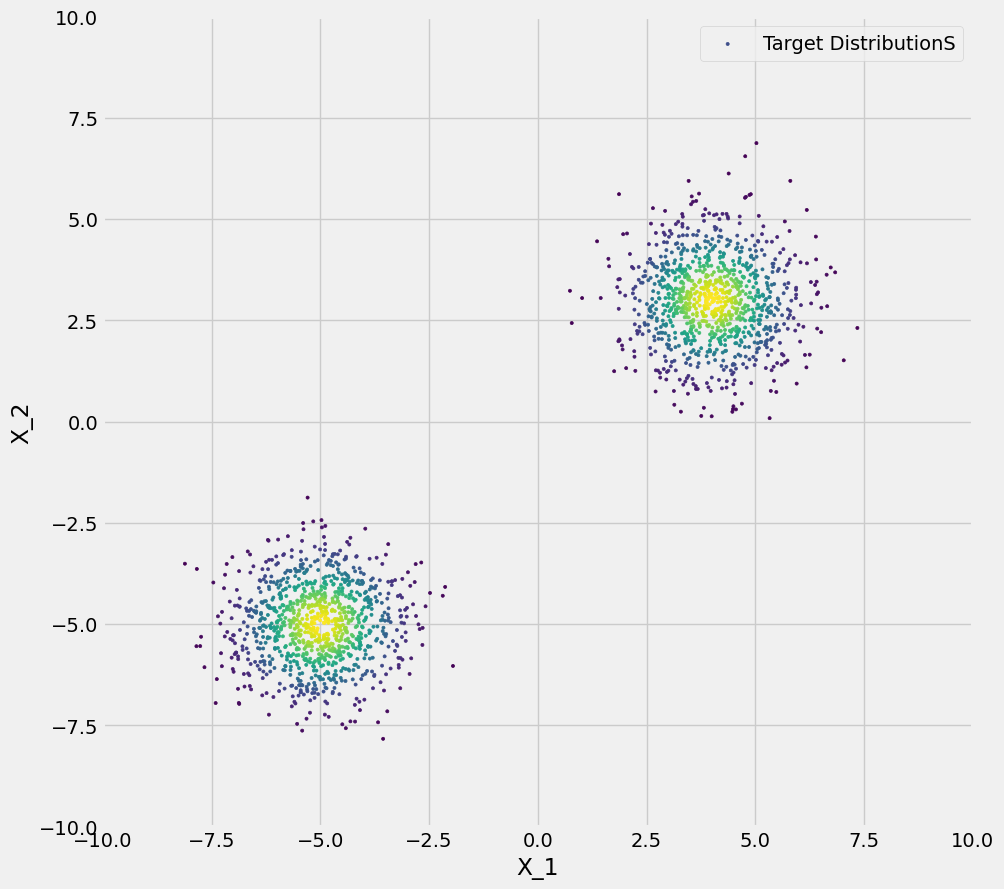

In [13]:
plt.figure(figsize=(10, 10))
plot_2d_dots(x, color=px, label='Target DistributionS')
plt.legend()
plt.show()

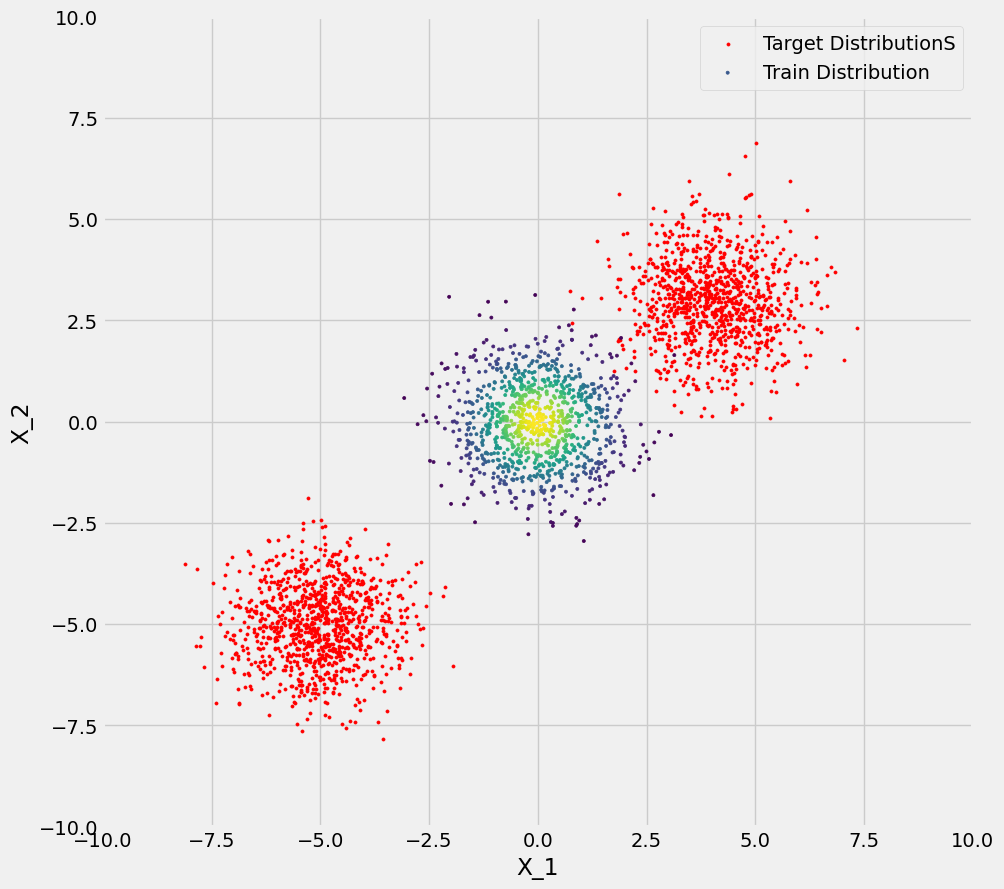

In [14]:
Q = DistributionHandler(0., 1.)

q_sample = Q.sample(1000)

qx = Q.distribution.log_prob(q_sample).exp()

plt.figure(figsize=(10, 10))
plot_2d_dots(x, color='r', label='Target DistributionS')
plot_2d_dots(q_sample, color=qx, label='Train Distribution')

plt.legend()
plt.show()

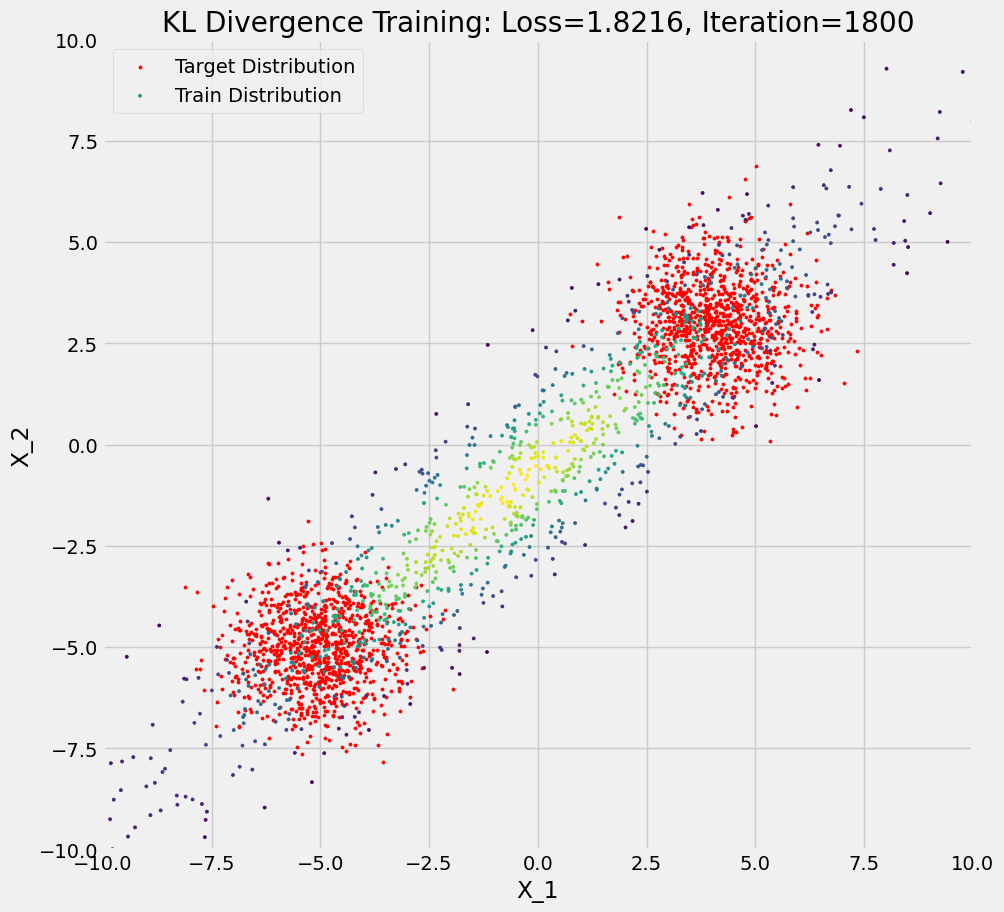

In [15]:
train_mu, train_sigma = Q.make_trainable()

train_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=2000, plot_interval=200, loss_fn=kl_loss, title='KL Divergence Training', weights=1./px)

KL divergence tries to match the distribution precisely, failing to converge into one of the modes

________

## JS Divergence Loss



The Jensen-Shannon (JS) divergence is a symmetric measure of similarity between two probability distributions, $P(x)$ and $Q(x)$.

Unlike the Kullback-Leibler (KL) divergence, it is always bounded between 0 and 1 (when using base-2 logarithms), making it a more stable metric for distribution comparison.

#### Formula
The JS divergence is defined as:
$$
D_{JS}(P \parallel Q) = \frac{1}{2} D_{KL}(P \parallel M) + \frac{1}{2} D_{KL}(Q \parallel M),
$$
where $M = \frac{1}{2} (P + Q)$ is the midpoint distribution

#### Intuition
1. The JS divergence computes the average of the KL divergences of each distribution to their midpoint.
2. It is symmetric: $D_{JS}(P \parallel Q) = D_{JS}(Q \parallel P)$.
3. It is always non-negative and bounded, ensuring better stability in optimization tasks.



In [16]:
def js_loss(qx, px, weights=None):
    """
    Compute the Jensen-Shannon (JS) divergence between two probability distributions.

    Parameters:
    qx (torch.Tensor): First probability distribution.
    px (torch.Tensor): Second probability distribution.
    weights (torch.Tensor, optional): Importance sampling weights (default None).

    Returns:
    torch.Tensor: The Jensen-Shannon divergence.
    """
    # Compute the midpoint distribution
    m = 0.5 * px + 0.5 * qx

    # Compute the JS divergence as the weighted average of KL divergences
    return 0.5 * kl_loss(px, m, weights) + 0.5 * kl_loss(qx, m, weights)

In [17]:
Q = DistributionHandler(-2.5, 1.)

train_mu, train_sigma = Q.make_trainable()

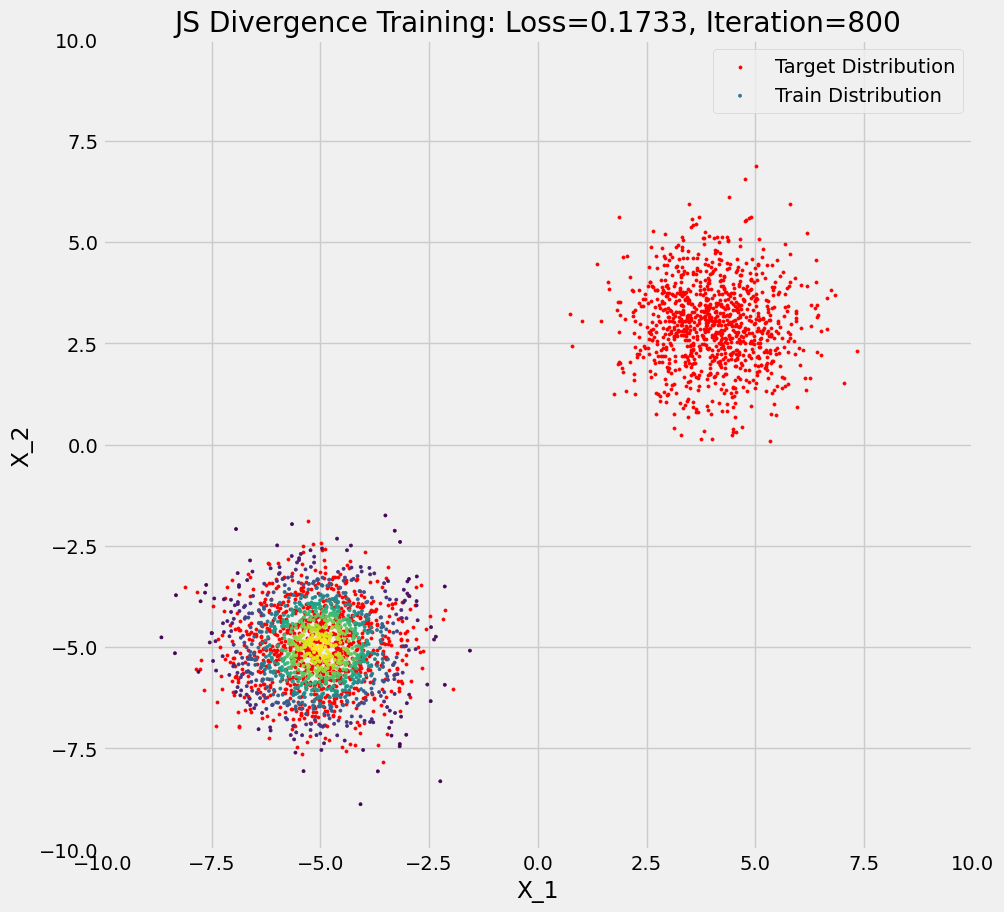

In [18]:
train_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=1000, plot_interval=200, loss_fn=js_loss, title='JS Divergence Training', weights=1./px)

JS Divergence provides balances the contributions of both distributions, resulting in a more symmetric and bounded optimization process.

______

## Least Squares (LS) for Distribution Modeling

#### Formula
The Least Squares objective can be defined as:
$$
L_{LS}(\theta) = \frac{1}{N} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2,
$$
where:
- $y_i$: Ground truth value for the $i$-th sample.
- $\hat{y}_i$: Predicted value for the $i$-th sample.
- $N$: Total number of samples.


In [19]:
def LSE_loss(qx, px):
    return torch.nn.functional.mse_loss(qx, px)

In [20]:
Q = DistributionHandler(1., 1.)

train_mu, train_sigma = Q.make_trainable()

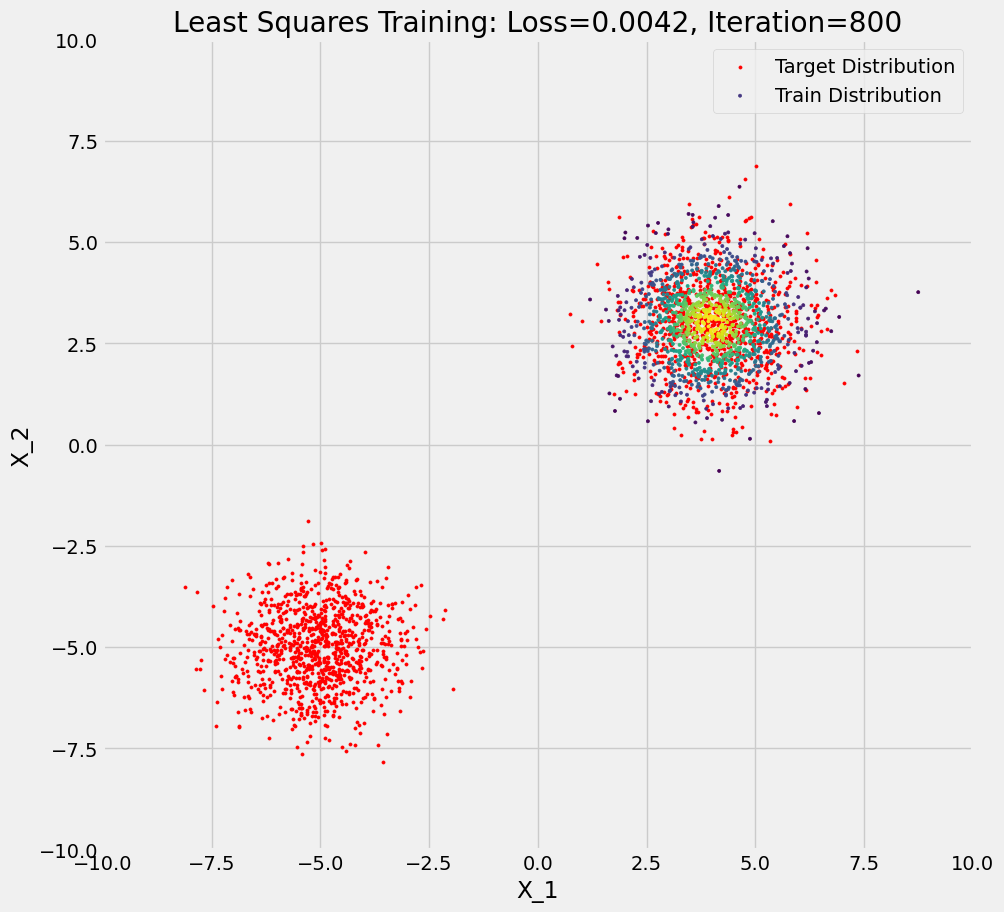

In [21]:
train_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=1000, plot_interval=200, loss_fn=LSE_loss, title='Least Squares Training')

In the context of Generative Adversarian Networks (GANs), the LS objective has been shown to improve stability and reduce issues such as vanishing gradients compared to the standard cross-entropy loss.

For the discriminator:
$$
L_D = \frac{1}{2} \mathbb{E}_{x \sim p_{data}}\left[(D(x) - b)^2\right] + \frac{1}{2} \mathbb{E}_{z \sim p_z}\left[(D(G(z)) - a)^2\right],
$$
where $a$ and $b$ are constants (e.g., $a=0$, $b=1$).

For the generator:
$$
L_G = \frac{1}{2} \mathbb{E}_{z \sim p_z}\left[(D(G(z)) - c)^2\right],
$$
where $c$ is a constant (e.g., $c=1$).

#### Intuition
1. The LS objective minimizes the mean squared error between predictions and targets.
2. In GANs, it helps encourage the generator to produce outputs that make the discriminator's predictions match a desired value (e.g., 1 for real data).
3. The LS objective smooths the loss landscape, improving stability during training.


Mao et al. (2016), [LSGAN](https://www.arxiv-vanity.com/papers/1611.04076/)


_______

## KL and JS on 1D Bimodal Data Distribution



### KL

In [22]:
mu1, sigma1 = -3, 0.5
mu2, sigma2 = -8, 0.5

target1 = distributions.Normal(mu1, sigma1)
target2 = distributions.Normal(mu2, sigma2)

x = torch.linspace(-10, 10, 1000)
px = target1.log_prob(x).exp() + target2.log_prob(x).exp()

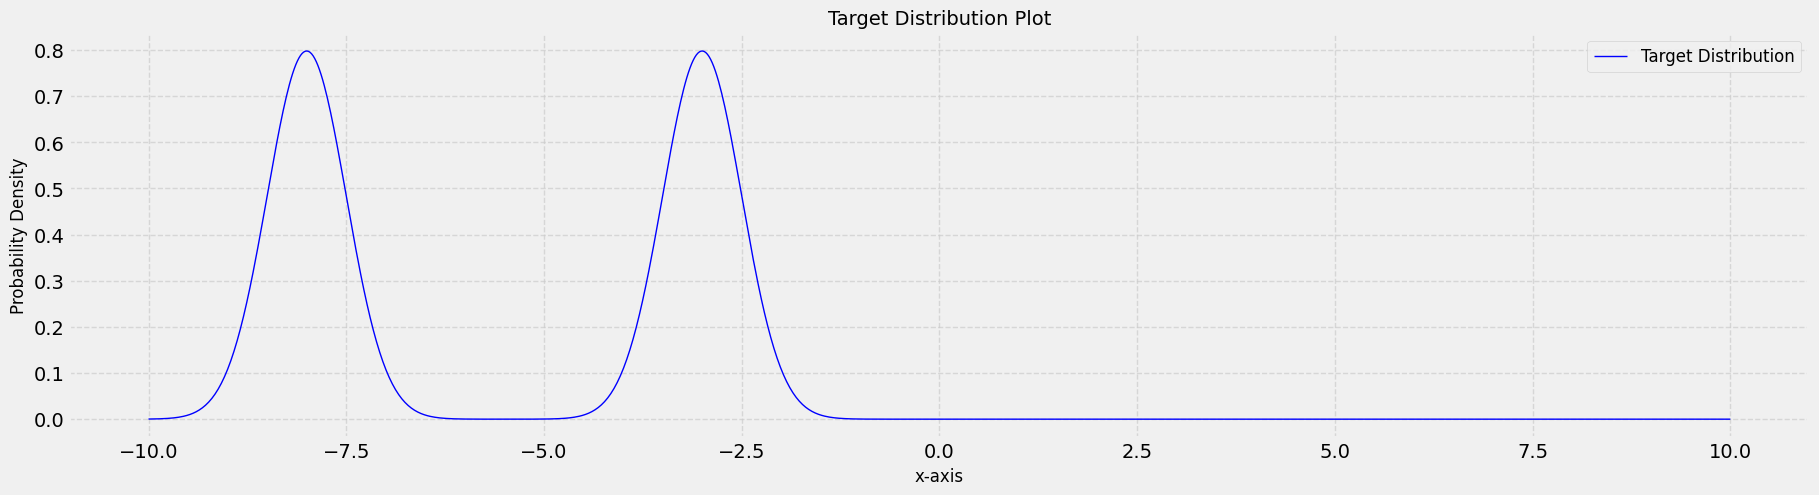

In [23]:
plt.figure(figsize=(20, 5))
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(x.numpy(), px.numpy(), linewidth=1, label='Target Distribution', color='blue')
plt.title('Target Distribution Plot', fontsize=14)
plt.xlabel('x-axis', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=12)
plt.show()

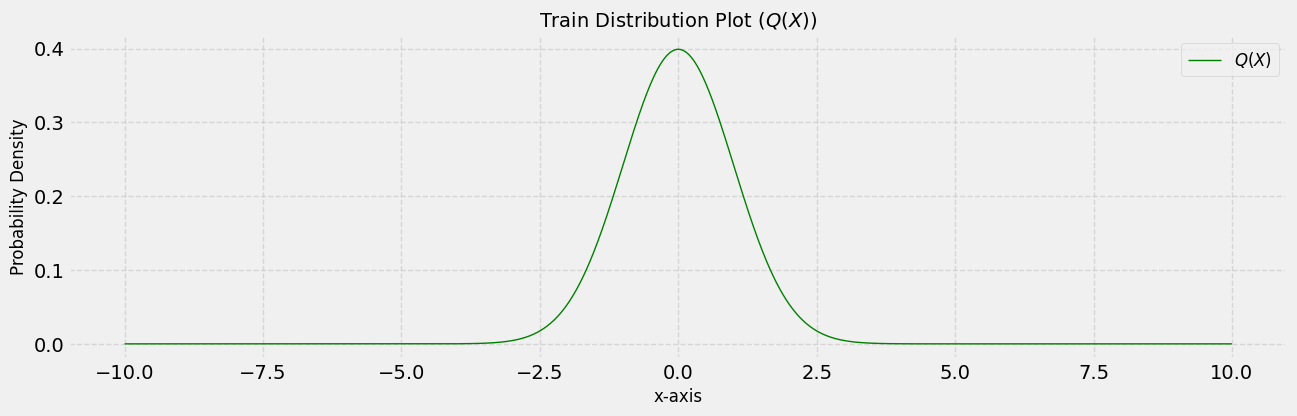

In [24]:
train_mu = torch.Tensor([0.0])
train_mu.requires_grad = True
train_sigma = torch.Tensor([1.0])
train_sigma.requires_grad = True

Q = distributions.Normal(train_mu, train_sigma)
qx = Q.log_prob(x).exp()

plt.figure(figsize=(14, 4))
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(x.numpy(), qx.detach().numpy(), linewidth=1, label='$Q(X)$', color='green')
plt.title('Train Distribution Plot ($Q(X)$)', fontsize=14)
plt.xlabel('x-axis', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [26]:
def train_1D_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=5000, plot_interval=200, loss_fn=kl_loss, method='KL', **loss_kwargs):
    optim = torch.optim.SGD([train_mu, train_sigma], lr=lr)
    grads_mu = []
    grads_sigma = []

    for i in range(iterations):
        optim.zero_grad()

        Q = distributions.Normal(train_mu, train_sigma)
        qx = Q.log_prob(x).exp()

        loss = loss_fn(qx, px)
        loss.backward()

        grads_mu.append(np.abs(train_mu.grad.item()))
        grads_sigma.append(np.abs(train_sigma.grad.item()))

        optim.step()

        if i % plot_interval == 0:
            clear_output(True)
            plt.figure(figsize=(20, 5))
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.plot(x.numpy(), px.numpy(), linewidth=1, label='Target Distribution', color='blue')
            plt.plot(x.numpy(), qx.detach().numpy(), linewidth=1, label='Train Distribution', color='orange')
            plt.title(f'$\mu={train_mu.item():.2f}, \sigma={train_sigma.item():.2f}, {method}={loss.item():.4f}, \text{{Iteration}}={i}$', fontsize=14)
            plt.xlabel('x-axis', fontsize=12)
            plt.ylabel('Probability Density', fontsize=12)
            plt.legend(fontsize=12)
            plt.show()

    return grads_mu, grads_sigma

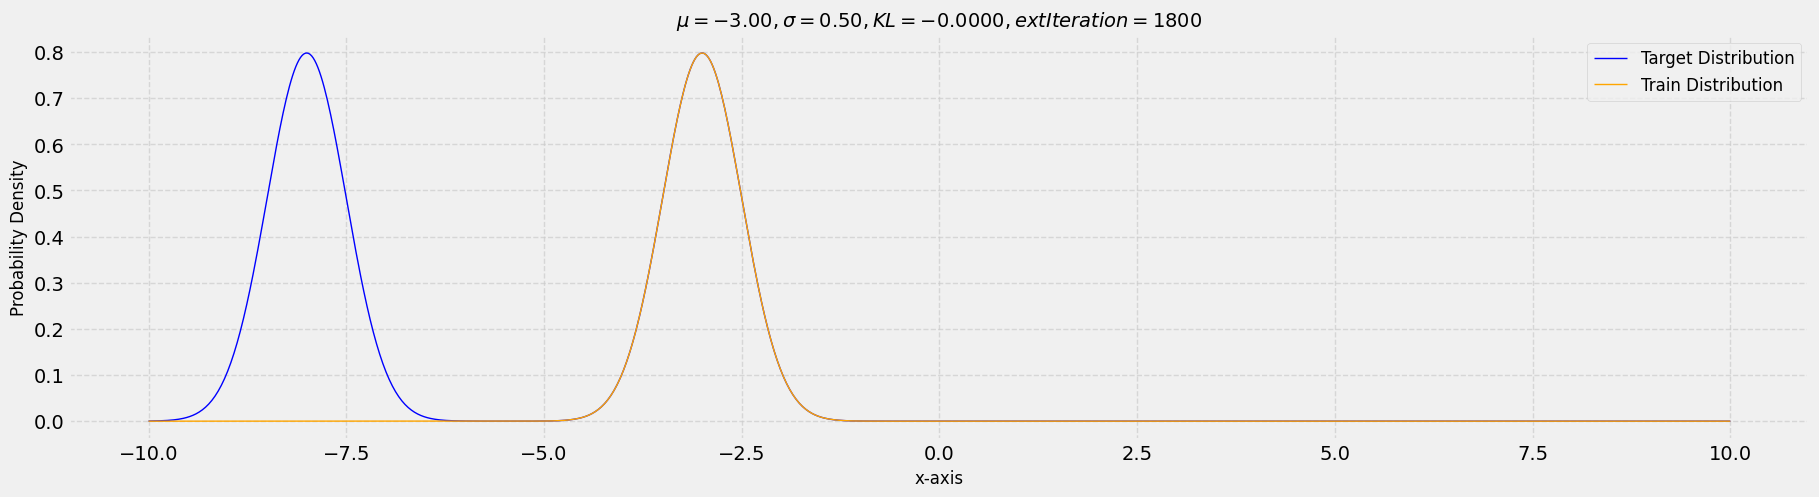

In [27]:
grads_mu, grads_sigma = train_1D_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=2000, plot_interval=200, loss_fn=kl_loss)

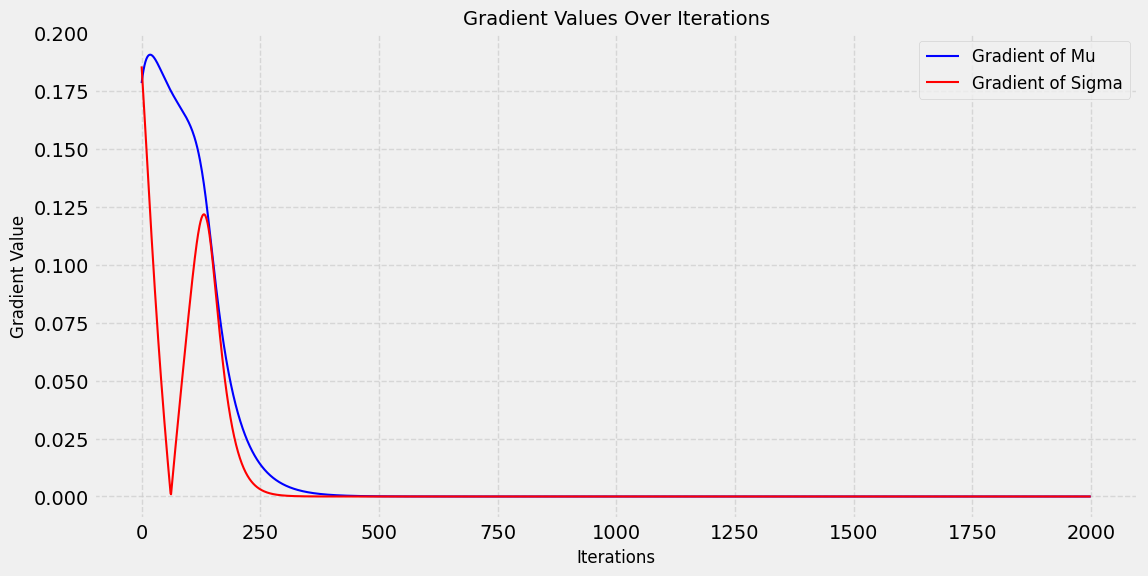

In [28]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(grads_mu, color='blue', linewidth=1.5, label='Gradient of Mu')
plt.plot(grads_sigma, color='red', linewidth=1.5, label='Gradient of Sigma')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Gradient Value", fontsize=12)
plt.title("Gradient Values Over Iterations", fontsize=14)
plt.legend(fontsize=12)
plt.show()

**KL Divergence** converges faster but at the cost of potential instability in the early stages due to sharp gradient spikes.

The rapid decay to zero might also reduce long-term optimization flexibility, particularly if the target distribution is not initially well-represented.

### JS

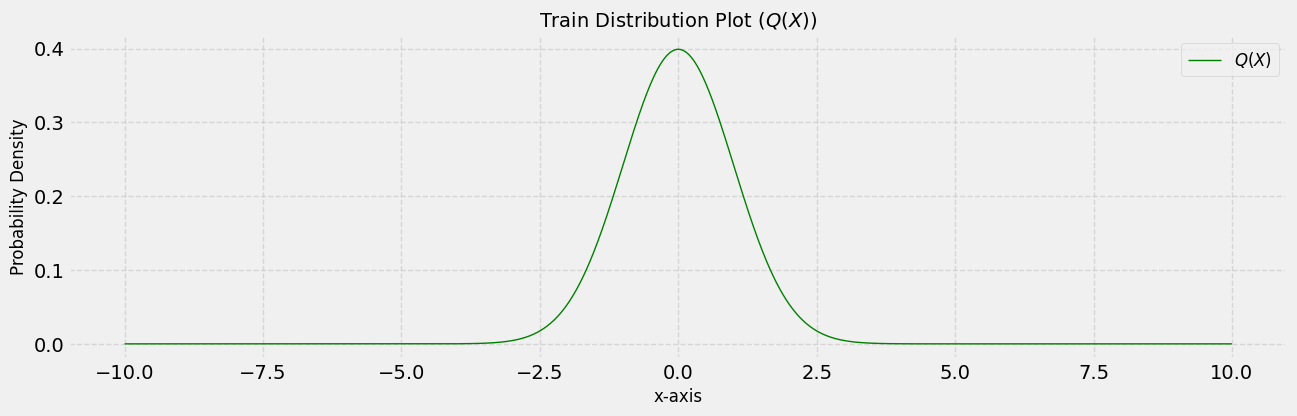

In [29]:
train_mu = torch.Tensor([0.0])
train_mu.requires_grad = True
train_sigma = torch.Tensor([1.0])
train_sigma.requires_grad = True

Q = distributions.Normal(train_mu, train_sigma)
qx = Q.log_prob(x).exp()

plt.figure(figsize=(14, 4))
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(x.numpy(), qx.detach().numpy(), linewidth=1, label='$Q(X)$', color='green')
plt.title('Train Distribution Plot ($Q(X)$)', fontsize=14)
plt.xlabel('x-axis', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=12)
plt.show()

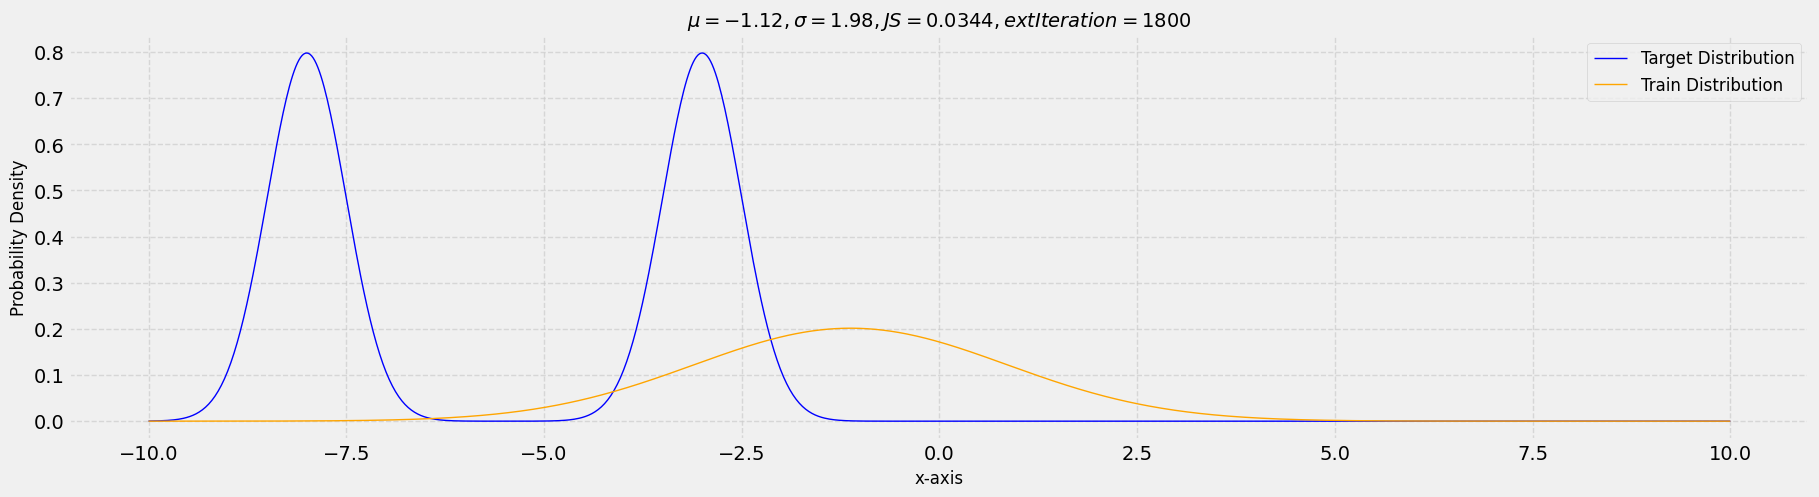

In [30]:
grads_mu, grads_sigma = train_1D_distribution(train_mu, train_sigma, px, x, lr=0.1, iterations=2000, plot_interval=300, loss_fn=js_loss, method="JS")

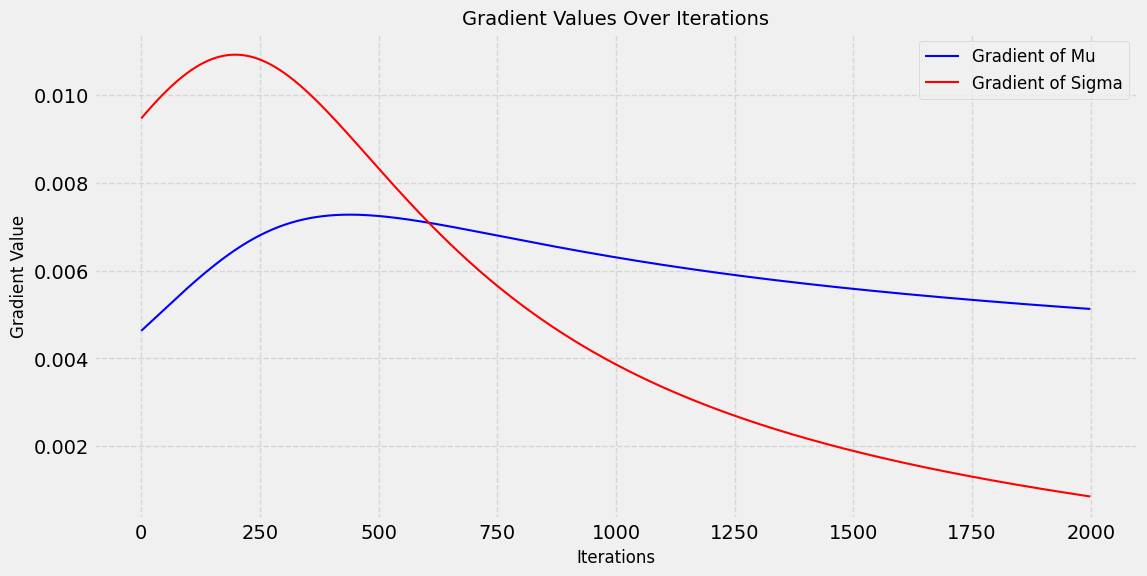

In [31]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot(grads_mu, color='blue', linewidth=1.5, label='Gradient of Mu')
plt.plot(grads_sigma, color='red', linewidth=1.5, label='Gradient of Sigma')
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Gradient Value", fontsize=12)
plt.title("Gradient Values Over Iterations", fontsize=14)
plt.legend(fontsize=12)
plt.show()

The slower decay of gradients suggests that JS divergence is less aggressive in its optimization, making it a good choice for tasks where stability and symmetry are more critical than rapid convergence.

____

***Conclusion***

Use **JS Divergence** for stability, symmetry, and tasks with noisy or imbalanced distributions.

Use **KL Divergence** for faster convergence and tasks with well-defined, precise target distributions.